# Notebook — Teste do módulo `spherical_harmonics.py`

Este notebook testa o módulo:

```python
geodesy/spherical_harmonics.py
```

Serão testadas as funções:

- `legendre_polynomial`
- `associated_legendre`
- `fully_normalized_legendre`
- `spherical_harmonic`
- `potential_from_coefficients`
- `degree_variance`
- `truncate_coefficients`

Os exemplos incluem curvas de Legendre, mapas globais de harmônicos esféricos e cálculo didático de potencial por coeficientes sintéticos.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import spherical_harmonics
from geodesy import constants

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Polinômios de Legendre


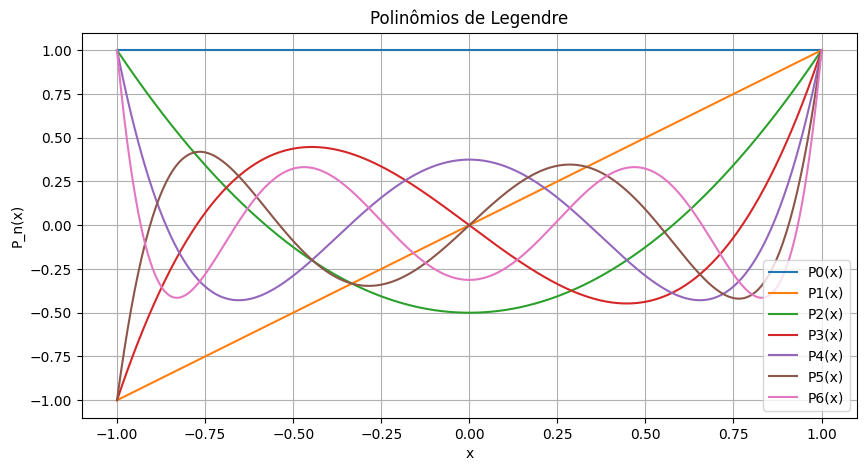

In [2]:
# ============================================================
# 1. POLINÔMIOS DE LEGENDRE
# ============================================================

x = np.linspace(-1, 1, 400)

plt.figure(figsize=(10, 5))

for n in range(0, 7):
    Pn = spherical_harmonics.legendre_polynomial(n, x)
    plt.plot(x, Pn, label=f"P{n}(x)")

plt.xlabel("x")
plt.ylabel("P_n(x)")
plt.title("Polinômios de Legendre")
plt.legend()
plt.grid(True)
plt.show()


## 2. Funções associadas de Legendre


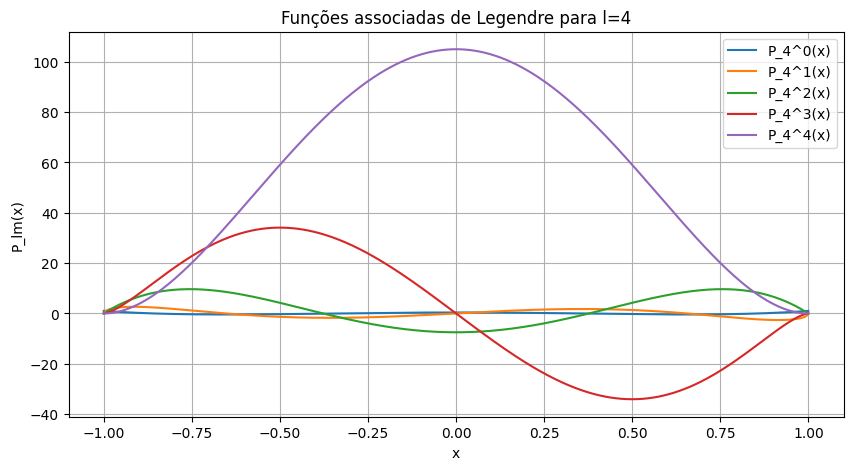

In [3]:
# ============================================================
# 2. LEGENDRE ASSOCIADO
# ============================================================

l = 4

plt.figure(figsize=(10, 5))

for m in range(0, l + 1):
    Plm = spherical_harmonics.associated_legendre(l, m, x)
    plt.plot(x, Plm, label=f"P_{l}^{m}(x)")

plt.xlabel("x")
plt.ylabel("P_lm(x)")
plt.title("Funções associadas de Legendre para l=4")
plt.legend()
plt.grid(True)
plt.show()


## 3. Legendre completamente normalizado


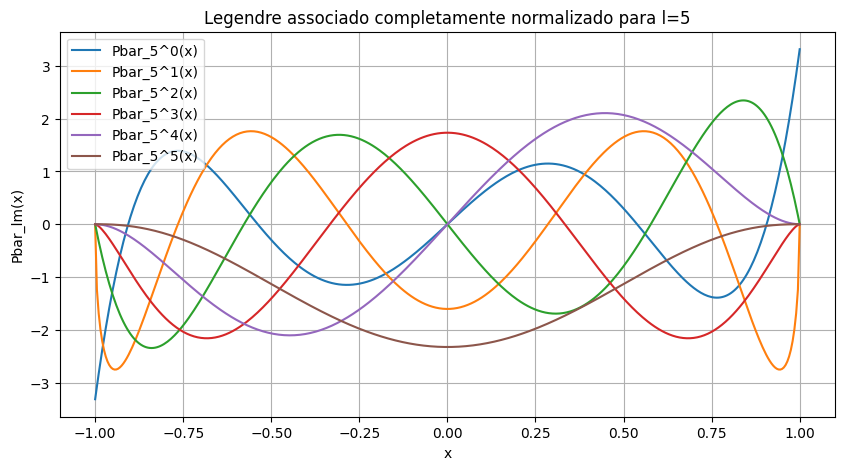

In [4]:
# ============================================================
# 3. LEGENDRE NORMALIZADO
# ============================================================

l = 5

plt.figure(figsize=(10, 5))

for m in range(0, l + 1):
    Pnorm = spherical_harmonics.fully_normalized_legendre(l, m, x)
    plt.plot(x, Pnorm, label=f"Pbar_{l}^{m}(x)")

plt.xlabel("x")
plt.ylabel("Pbar_lm(x)")
plt.title("Legendre associado completamente normalizado para l=5")
plt.legend()
plt.grid(True)
plt.show()


## 4. Harmônico esférico real em latitude-longitude


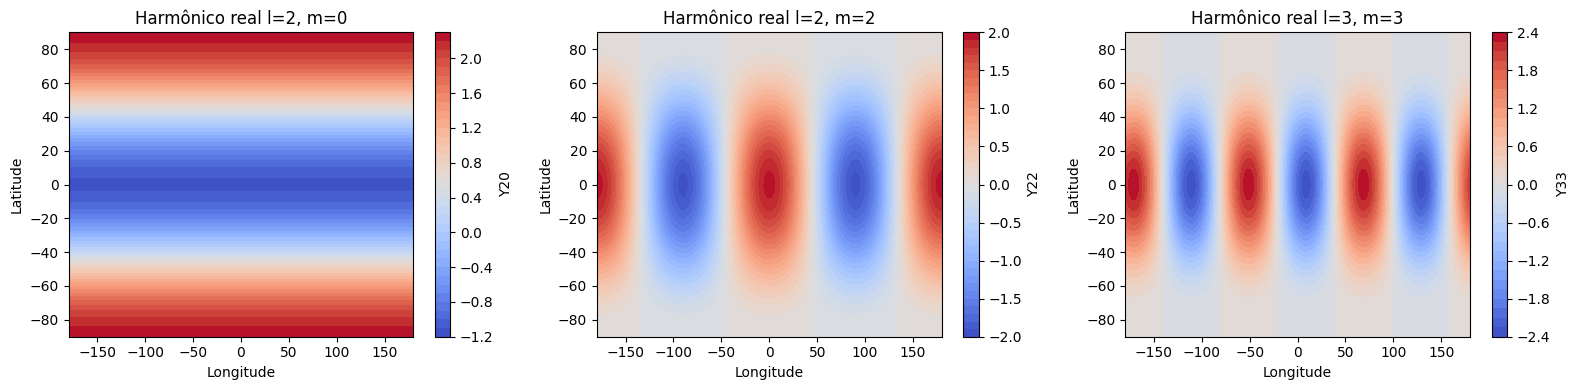

In [5]:
# ============================================================
# 4. HARMÔNICO ESFÉRICO REAL
# ============================================================

lon = np.linspace(-180, 180, 361)
lat = np.linspace(-90, 90, 181)

LON, LAT = np.meshgrid(lon, lat)

Y_20 = spherical_harmonics.spherical_harmonic(2, 0, LAT, LON, C=1.0, S=0.0)
Y_22 = spherical_harmonics.spherical_harmonic(2, 2, LAT, LON, C=1.0, S=0.0)
Y_33 = spherical_harmonics.spherical_harmonic(3, 3, LAT, LON, C=1.0, S=0.5)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, Y_20, levels=40, cmap="coolwarm")
plt.colorbar(c1, label="Y20")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Harmônico real l=2, m=0")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, Y_22, levels=40, cmap="coolwarm")
plt.colorbar(c2, label="Y22")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Harmônico real l=2, m=2")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, Y_33, levels=40, cmap="coolwarm")
plt.colorbar(c3, label="Y33")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Harmônico real l=3, m=3")

plt.tight_layout()
plt.show()


## 5. Potencial por coeficientes sintéticos


Potencial min/max: 62339278.57488185 62646041.54358614


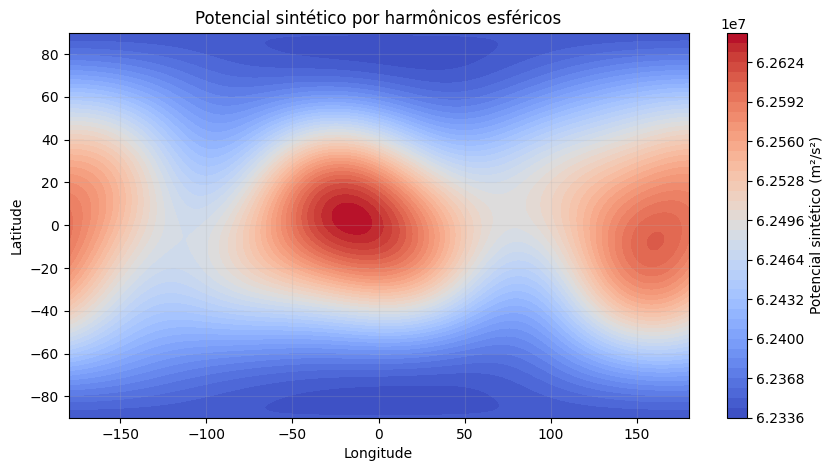

In [7]:
# ============================================================
# 5. POTENCIAL POR COEFICIENTES SINTÉTICOS
# ============================================================

lmax = 6

C = np.zeros((lmax + 1, lmax + 1))
S = np.zeros((lmax + 1, lmax + 1))

# Coeficientes sintéticos didáticos
C[0, 0] = 1.0
C[2, 0] = -0.001
C[2, 2] = 0.0005
S[2, 2] = -0.0003
C[3, 1] = 0.0002
S[4, 3] = 0.00015

r = constants.WGS84_A + 1000.0

V = spherical_harmonics.potential_from_coefficients(
    LAT,
    LON,
    r,
    C,
    S,
    lmax=lmax
)

print("Potencial min/max:", np.nanmin(V), np.nanmax(V))

plt.figure(figsize=(10, 5))
c = plt.contourf(LON, LAT, V, cmap="coolwarm", levels=40)
plt.colorbar(c, label="Potencial sintético (m²/s²)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Potencial sintético por harmônicos esféricos")
plt.grid(alpha=0.2)
plt.show()


## 6. Variância por grau


Variância por grau:
0 1.0
1 0.0
2 1.3399999999999999e-06
3 4e-08
4 2.2499999999999996e-08
5 0.0
6 0.0


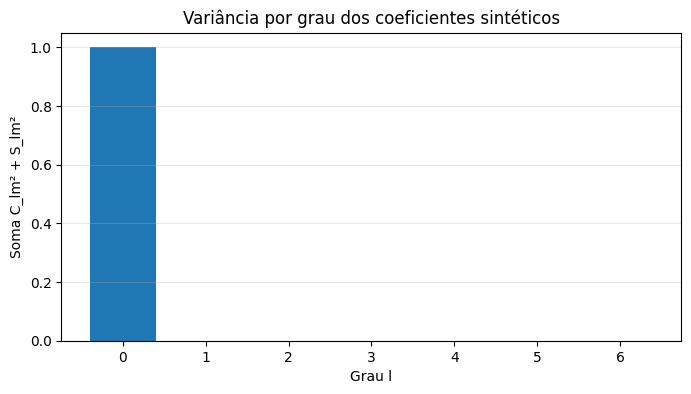

In [8]:
# ============================================================
# 6. VARIÂNCIA POR GRAU
# ============================================================

deg_var = spherical_harmonics.degree_variance(C, S, lmax=lmax)

print("Variância por grau:")
for l, v in enumerate(deg_var):
    print(l, v)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(lmax + 1), deg_var)
plt.xlabel("Grau l")
plt.ylabel("Soma C_lm² + S_lm²")
plt.title("Variância por grau dos coeficientes sintéticos")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Truncamento de coeficientes


In [9]:
# ============================================================
# 7. TRUNCAMENTO
# ============================================================

Ct, St = spherical_harmonics.truncate_coefficients(C, S, lmax=3)

print("Shape original C:", C.shape)
print("Shape truncado Ct:", Ct.shape)

print("Ct:")
print(Ct)

print("St:")
print(St)


Shape original C: (7, 7)
Shape truncado Ct: (4, 4)
Ct:
[[ 1.e+00  0.e+00  0.e+00  0.e+00]
 [ 0.e+00  0.e+00  0.e+00  0.e+00]
 [-1.e-03  0.e+00  5.e-04  0.e+00]
 [ 0.e+00  2.e-04  0.e+00  0.e+00]]
St:
[[ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.     -0.0003  0.    ]
 [ 0.      0.      0.      0.    ]]


## 8. Mapas com Cartopy em Mollweide


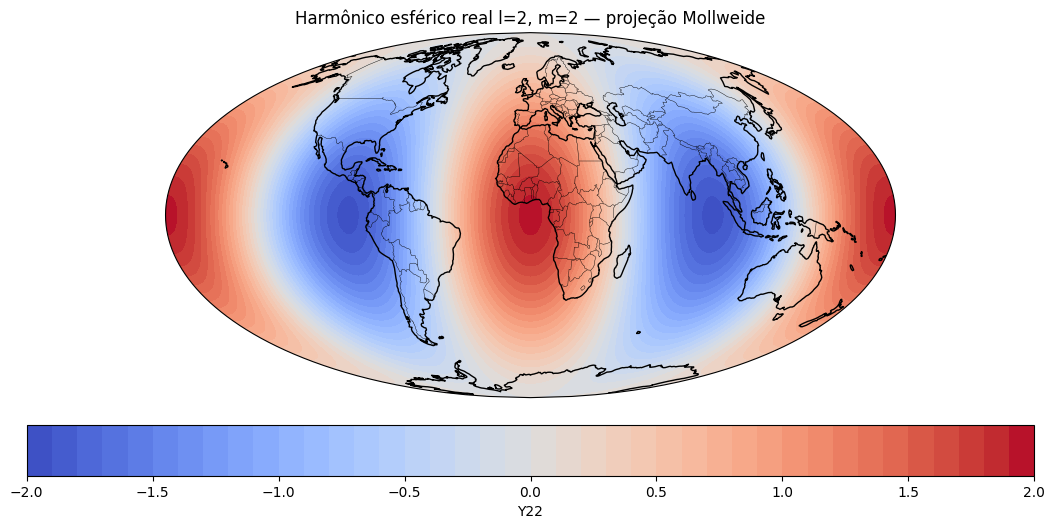

In [10]:
# ============================================================
# 8. MAPAS EM CARTOPY / MOLLWEIDE
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=ccrs.Mollweide())

cf = ax.contourf(
    LON, LAT, Y_22,
    levels=40,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()

cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06)
cbar.set_label("Y22")

ax.set_title("Harmônico esférico real l=2, m=2 — projeção Mollweide")
plt.show()


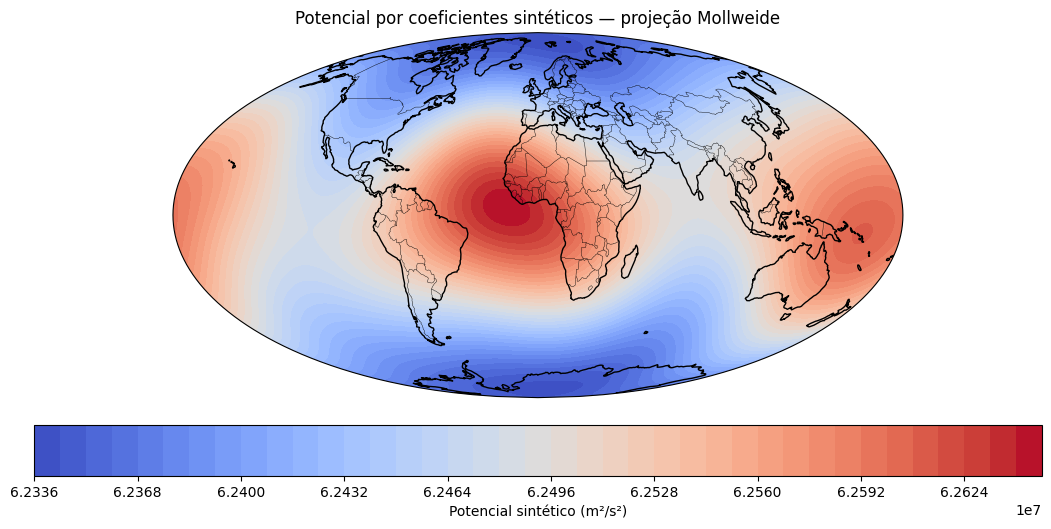

In [12]:
fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=ccrs.Mollweide())

cf = ax.contourf(
    LON, LAT, V, cmap="coolwarm",
    levels=40,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()

cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06)
cbar.set_label("Potencial sintético (m²/s²)")

ax.set_title("Potencial por coeficientes sintéticos — projeção Mollweide")
plt.show()


## 9. Resumo final


Se todas as células foram executadas sem erro, o módulo `spherical_harmonics.py` está funcionando corretamente.

O próximo notebook testa:

```python
geodesy/terrain_effects.py
```
